# PRÁCTICA 2

In [1]:
import pickle
import numpy as np
import sys
import os
import xgboost as xgb

# ==============================================================================
# CARGA DE PIPELINES (Añadido con parche de rutas)
# ==============================================================================
sys.path.append(os.getcwd())

with open('preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

with open('filter.pkl', 'rb') as f:
    feature_filter = pickle.load(f)

print("Pipelines (preprocessor y filter) cargados correctamente.")

# ==============================================================================
# CARGA DE DATOS FILTRADOS (Estructura original del profesor)
# ==============================================================================
with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_filtered = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_filtered = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)

y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# scale_pos_weight para XGBoost (LightGBM puede usar class_weight='balanced')
n_negative = np.sum(~y_train_flat)
n_positive = np.sum(y_train_flat)
scale_pos_weight = n_negative / n_positive

print(f"Train: {X_train_filtered.shape}  |  Test: {X_test_filtered.shape}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Pipelines (preprocessor y filter) cargados correctamente.
Train: (80000, 163)  |  Test: (20000, 163)
scale_pos_weight = 3.93


In [2]:
# Split interno train/val para la optimizacion con TPE, el test solo lo usamos al final para evitar data leakage
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_filtered, y_train_flat,
    test_size=0.2, random_state=42, stratify=y_train_flat
)
print(f"Train interno: {X_tr.shape}  |  Val interno: {X_val.shape}")

Train interno: (64000, 163)  |  Val interno: (16000, 163)


In [3]:
from sklearn.metrics import log_loss, roc_auc_score, recall_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name, results_dict):
    """
    Escogí Log Loss por varias razones:
    1- Era la recomendada el las instrucciones
    2- No es un error binario, le da importancia a la probabilidad de la predicción del modelo
    3- Penaliza los errores graves, forzando al modelo a ser más conservador
    Esta última es especialmente importante en la detección de impagos porque puede suponer una gran pérdida económica
    """
    # Obtenemos probabilidades para el Log Loss
    prob_pred = model.predict_proba(X_test)[:, 1]
    # Obtenemos clases para el Classification Report (Recall/F1)
    class_pred = model.predict(X_test)
    
    # Cálculo de la métrica
    logloss_val = log_loss(y_test, prob_pred)
    
    # Guardamos solo lo relevante para la comparativa final
    results_dict[model_name] = {
        'Log Loss (Objetivo)': logloss_val,
        'AUC-ROC': roc_auc_score(y_test, prob_pred),
        'Recall (Default)': recall_score(y_test, class_pred)
    }
    
    print(f"\n{'='*60}\n  EVALUACIÓN: {model_name}\n{'='*60}")
    print(f"  LOG LOSS: {logloss_val:.4f} (Métrica principal)")
    print("-" * 60)
    print(classification_report(y_test, class_pred, target_names=["Fully Paid", "Default"]))
    
    return results_dict

# Inicializamos el diccionario de resultados
results = {}

EMPEZAMOS EL ENUNCIADO, LO DE ARRIBA ERA FILTRADO DE DATOS Y COSAS INICIALES

In [4]:
import optuna
from optuna.integration import LightGBMPruningCallback
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import log_loss

def objective_lgbm(trial: optuna.Trial, balanceado=False) -> float:
    params = {
        'objective': 'binary',
        'metric':'binary_logloss',
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),

        'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.5, 1.0),

        'class_weight': 'balanced' if balanceado else None,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = LGBMClassifier(**params)

    pruning_cb = LightGBMPruningCallback(trial, metric='binary_logloss', valid_name='valid_0')

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb]
    )

    prob_val = model.predict_proba(X_val)[:, 1]
    return log_loss(y_val, prob_val)

c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import optuna
from xgboost import XGBClassifier
from optuna.integration import XGBoostPruningCallback
from sklearn.metrics import log_loss
def objective_xgb(trial: optuna.Trial, balanceado=False) -> float:
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-2, 20, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight if balanceado else 1.0,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'early_stopping_rounds': 50 
    }

    pruning_cb = XGBoostPruningCallback(trial, 'validation_0-logloss')

    model = xgb.XGBClassifier(**params, callbacks=[pruning_cb])

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    prob_val = model.predict_proba(X_val)[:, 1]
    return log_loss(y_val, prob_val)

In [6]:
# Configuramos el logging para que no ensucie la salida
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Definición del Sampler (TPE) - Variación: multivariate=True y startup_trials=15
sampler = optuna.samplers.TPESampler(
    n_startup_trials=15,    
    multivariate=True,      
    seed=42
)

# 2. Definición del Pruner - Variación: Hyperband en lugar de Median
# He escogido Hyperband para hacer una purga más eficiente a nivel de tiempo de ejecución
# Hyperband crea muchas combinaciones de parámetros de forma simultánea, detectando las peores y haciendo un early stopping, dándonos un mejor tiempo de ejecución
pruner = optuna.pruners.HyperbandPruner(
    min_resource=1,
    reduction_factor=3
)

# ==============================================================================
# ESTUDIOS XGBOOST
# ==============================================================================

# --- ESTUDIO 1: XGBOOST SIN BALANCEO ---
study_xgb_unbalanced = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='xgb_unbalanced')
print("\nOptimizando XGBoost (Sin Balanceo)...")
study_xgb_unbalanced.optimize(lambda t: objective_xgb(t, balanceado=False), n_trials=30, show_progress_bar=True)

# --- ESTUDIO 2: XGBOOST CON BALANCEO ---
study_xgb_balanced = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='xgb_balanced')
print("\nOptimizando XGBoost (Con Balanceo)...")
study_xgb_balanced.optimize(lambda t: objective_xgb(t, balanceado=True), n_trials=30, show_progress_bar=True)

# ==============================================================================
# ESTUDIOS LIGHTGBM
# ==============================================================================

# --- ESTUDIO 3: LGBM SIN BALANCEO ---
study_lgbm_unbalanced = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='lgbm_unbalanced')
print("Optimizando LightGBM (Sin Balanceo)...")
study_lgbm_unbalanced.optimize(lambda t: objective_lgbm(t, balanceado=False), n_trials=30, show_progress_bar=True)

# --- ESTUDIO 4: LGBM CON BALANCEO ---
study_lgbm_balanced = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='lgbm_balanced')
print("\nOptimizando LightGBM (Con Balanceo)...")
study_lgbm_balanced.optimize(lambda t: objective_lgbm(t, balanceado=True), n_trials=30, show_progress_bar=True)



# ==============================================================================
# RESUMEN DE RESULTADOS DE OPTIMIZACIÓN (Validation LogLoss)
# ==============================================================================
print(f"\n{'='*40}")
print(f"  RESULTADOS DE OPTIMIZACIÓN (BEST LOGLOSS)")
print(f"{'='*40}")
print(f"LGBM Standard:  {study_lgbm_unbalanced.best_value:.4f}")
print(f"LGBM Balanced:  {study_lgbm_balanced.best_value:.4f}")
print(f"XGB Standard:   {study_xgb_unbalanced.best_value:.4f}")
print(f"XGB Balanced:   {study_xgb_balanced.best_value:.4f}")

c:\Users\jesus\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(



Optimizando XGBoost (Sin Balanceo)...


Best trial: 2. Best value: 0.459389: 100%|██████████| 30/30 [02:23<00:00,  4.79s/it]



Optimizando XGBoost (Con Balanceo)...


Best trial: 26. Best value: 0.489518: 100%|██████████| 30/30 [05:24<00:00, 10.81s/it]


...

[W 2026-05-15 23:18:42,581] The parameter `num_leaves` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-05-15 23:18:42,590] The parameter `min_child_samples` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-05-15 23:18:42,599] The parameter `min_split_gain` in Trial#28 is sampled independent

Best trial: 10. Best value: 0.500619:  97%|█████████▋| 29/30 [02:11<00:01,  1.09s/it]

[W 2026-05-15 23:18:43,392] The parameter `num_leaves` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-05-15 23:18:43,402] The parameter `min_child_samples` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.
[W 2026-05-15 23:18:43,410] The parameter `min_split_gain` in Trial#29 is sampled independent

Best trial: 10. Best value: 0.500619: 100%|██████████| 30/30 [02:12<00:00,  4.43s/it]


  RESULTADOS DE OPTIMIZACIÓN (BEST LOGLOSS)
LGBM Standard:  0.4593
LGBM Balanced:  0.5006
XGB Standard:   0.4594
XGB Balanced:   0.4895


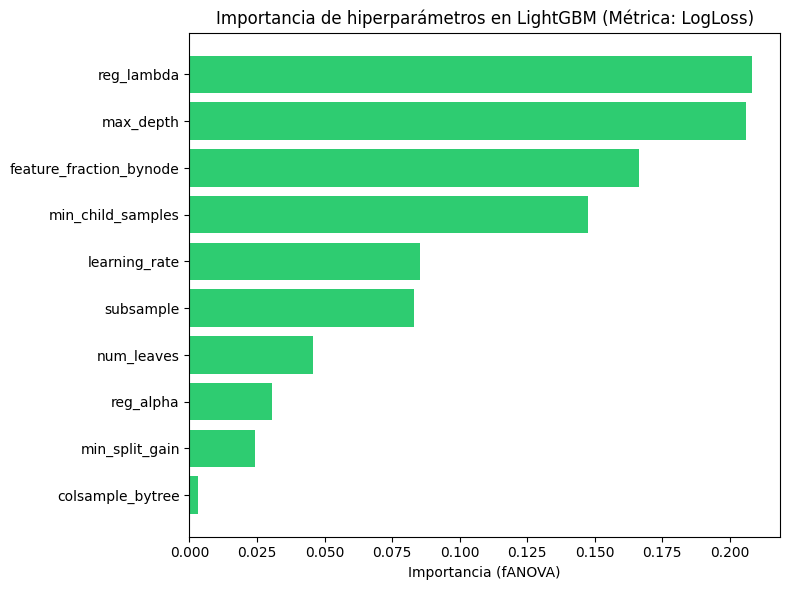

Ranking de importancia de hiperparámetros:
  reg_lambda                0.208
  max_depth                 0.206
  feature_fraction_bynode   0.166
  min_child_samples         0.147
  learning_rate             0.085
  subsample                 0.083
  num_leaves                0.046
  reg_alpha                 0.031
  min_split_gain            0.024
  colsample_bytree          0.003


In [7]:
import matplotlib.pyplot as plt

# Usamos el estudio balanceado de LightGBM como referencia para la importancia
importances = optuna.importance.get_param_importances(study_lgbm_balanced)

fig, ax = plt.subplots(figsize=(8, 6))
params_sorted = list(importances.keys())[::-1]
values_sorted = [importances[p] for p in params_sorted]

ax.barh(params_sorted, values_sorted, color='#2ecc71')
ax.set_xlabel('Importancia (fANOVA)')
ax.set_title('Importancia de hiperparámetros en LightGBM (Métrica: LogLoss)')

plt.tight_layout()
plt.show()

print("Ranking de importancia de hiperparámetros:")
for p, v in importances.items():
    print(f"  {p:25s} {v:.3f}")

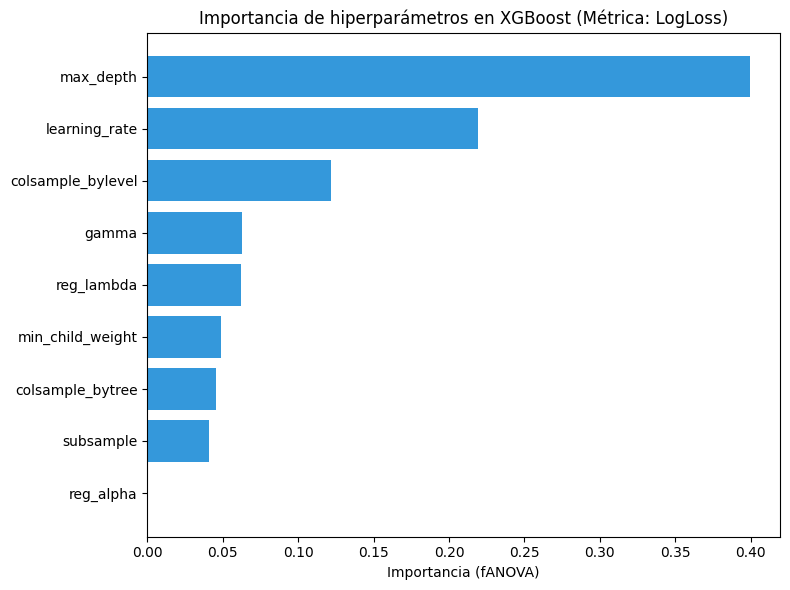

Ranking de importancia de hiperparámetros (XGBoost):
  max_depth                 0.399
  learning_rate             0.219
  colsample_bylevel         0.122
  gamma                     0.063
  reg_lambda                0.062
  min_child_weight          0.049
  colsample_bytree          0.045
  subsample                 0.041
  reg_alpha                 0.000


In [8]:
import matplotlib.pyplot as plt

# Importancia de hiperparámetros en el estudio balanceado de XGBoost
importances_xgb = optuna.importance.get_param_importances(study_xgb_balanced)

fig, ax = plt.subplots(figsize=(8, 6))
params_sorted = list(importances_xgb.keys())[::-1]
values_sorted = [importances_xgb[p] for p in params_sorted]

ax.barh(params_sorted, values_sorted, color='#3498db')
ax.set_xlabel('Importancia (fANOVA)')
ax.set_title('Importancia de hiperparámetros en XGBoost (Métrica: LogLoss)')

plt.tight_layout()
plt.show()

print("Ranking de importancia de hiperparámetros (XGBoost):")
for p, v in importances_xgb.items():
    print(f"  {p:25s} {v:.3f}")

In [9]:
# 1. ENTRENAMIENTO MODELO SIN BALANCEO LGBM
print("Entrenando modelo final LightGBM (Sin Balanceo)...")
best_params_unb = dict(study_lgbm_unbalanced.best_params)
best_params_unb.update({
    'objective': 'binary',
    'metric': 'binary_logloss',
    'n_estimators': 2000, # Más iteraciones para que el early stopping decida
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
})

lgbm_unb_final = LGBMClassifier(**best_params_unb)
lgbm_unb_final.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# 2. ENTRENAMIENTO MODELO CON BALANCEO
print("\nEntrenando modelo final LightGBM (Con Balanceo)...")
best_params_bal = dict(study_lgbm_balanced.best_params)
best_params_bal.update({
    'objective': 'binary',
    'metric': 'binary_logloss',
    'n_estimators': 2000,
    'class_weight': 'balanced', # Parámetro clave del enunciado
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
})

lgbm_bal_final = LGBMClassifier(**best_params_bal)
lgbm_bal_final.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# 3. EVALUACIÓN EN TEST (Usando la función evaluate_model del notebook)
# Aquí usamos X_test_filtered y y_test_flat que son los datos que el modelo NO ha visto
results = evaluate_model(lgbm_unb_final, X_test_filtered, y_test_flat, 'LGBM_Standard_LogLoss', results)
results = evaluate_model(lgbm_bal_final, X_test_filtered, y_test_flat, 'LGBM_Balanced_LogLoss', results)

# Mostrar tabla comparativa
import pandas as pd
df_res = pd.DataFrame(results).T
display(df_res)

Entrenando modelo final LightGBM (Sin Balanceo)...

Entrenando modelo final LightGBM (Con Balanceo)...

  EVALUACIÓN: LGBM_Standard_LogLoss
  LOG LOSS: 0.4555 (Métrica principal)
------------------------------------------------------------
              precision    recall  f1-score   support

  Fully Paid       0.81      0.98      0.89     16003
     Default       0.54      0.08      0.14      3997

    accuracy                           0.80     20000
   macro avg       0.68      0.53      0.51     20000
weighted avg       0.76      0.80      0.74     20000


  EVALUACIÓN: LGBM_Balanced_LogLoss
  LOG LOSS: 0.4966 (Métrica principal)
------------------------------------------------------------
              precision    recall  f1-score   support

  Fully Paid       0.83      0.90      0.86     16003
     Default       0.39      0.27      0.32      3997

    accuracy                           0.77     20000
   macro avg       0.61      0.58      0.59     20000
weighted avg       0.74 

,Log Loss (Objetivo),AUC-ROC,Recall (Default)
LGBM_Standard_LogLoss,0.455549,0.707572,0.079309
LGBM_Balanced_LogLoss,0.496635,0.685991,0.270703


In [10]:
# 1. ENTRENAMIENTO MODELO SIN BALANCEO XGB
print("Entrenando modelo final XGBoost (Sin Balanceo)...")
best_params_xgb_unb = dict(study_xgb_unbalanced.best_params)
best_params_xgb_unb.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 2000,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50
})

xgb_unb_final = XGBClassifier(**best_params_xgb_unb)
xgb_unb_final.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 2. ENTRENAMIENTO MODELO CON BALANCEO
print("\nEntrenando modelo final XGBoost (Con Balanceo)...")
best_params_xgb_bal = dict(study_xgb_balanced.best_params)
best_params_xgb_bal.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 2000,
    'scale_pos_weight': scale_pos_weight, # Equivalente a class_weight
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50
})

xgb_bal_final = XGBClassifier(**best_params_xgb_bal)
xgb_bal_final.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 3. EVALUACIÓN EN TEST
# Añadimos los resultados de XGBoost a la tabla compartida
results = evaluate_model(xgb_unb_final, X_test_filtered, y_test_flat, 'XGB_Standard_LogLoss', results)
results = evaluate_model(xgb_bal_final, X_test_filtered, y_test_flat, 'XGB_Balanced_LogLoss', results)

# Mostrar tabla comparativa final con los 4 modelos
df_res = pd.DataFrame(results).T
display(df_res)

Entrenando modelo final XGBoost (Sin Balanceo)...

Entrenando modelo final XGBoost (Con Balanceo)...

  EVALUACIÓN: XGB_Standard_LogLoss
  LOG LOSS: 0.4555 (Métrica principal)
------------------------------------------------------------
              precision    recall  f1-score   support

  Fully Paid       0.81      0.98      0.89     16003
     Default       0.55      0.09      0.16      3997

    accuracy                           0.80     20000
   macro avg       0.68      0.54      0.52     20000
weighted avg       0.76      0.80      0.74     20000


  EVALUACIÓN: XGB_Balanced_LogLoss
  LOG LOSS: 0.4842 (Métrica principal)
------------------------------------------------------------
              precision    recall  f1-score   support

  Fully Paid       0.83      0.93      0.87     16003
     Default       0.43      0.22      0.29      3997

    accuracy                           0.78     20000
   macro avg       0.63      0.57      0.58     20000
weighted avg       0.75     

,Log Loss (Objetivo),AUC-ROC,Recall (Default)
LGBM_Standard_LogLoss,0.455549,0.707572,0.079309
LGBM_Balanced_LogLoss,0.496635,0.685991,0.270703
XGB_Standard_LogLoss,0.455546,0.708083,0.090318
XGB_Balanced_LogLoss,0.484185,0.683405,0.215662


In [11]:
import xgboost as xgb
import lightgbm as lgb

# --- 1. LIGHTGBM FINAL ---
print("Entrenando LightGBM Finales...")
lgbm_unb_final = lgb.LGBMClassifier(**study_lgbm_unbalanced.best_params, n_estimators=2000, random_state=42, n_jobs=-1, verbose=-1)
lgbm_unb_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])

lgbm_bal_final = lgb.LGBMClassifier(**study_lgbm_balanced.best_params, n_estimators=2000, random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')
lgbm_bal_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])


# --- 2. XGBOOST FINAL ---
print("Entrenando XGBoost Finales...")

# Standard
xgb_unb_final = xgb.XGBClassifier(
    **study_xgb_unbalanced.best_params, 
    n_estimators=2000, 
    random_state=42, 
    n_jobs=-1,
    early_stopping_rounds=50  # Se pone aquí
)
# Fit sin callbacks
xgb_unb_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

# Balanced
xgb_bal_final = xgb.XGBClassifier(
    **study_xgb_balanced.best_params, 
    n_estimators=2000, 
    random_state=42, 
    n_jobs=-1, 
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50  # Se pone aquí
)
# Fit sin callbacks
xgb_bal_final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print("Todos los modelos finales entrenados con éxito.")

Entrenando LightGBM Finales...
Entrenando XGBoost Finales...
Todos los modelos finales entrenados con éxito.


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    matthews_corrcoef, roc_auc_score, average_precision_score, log_loss
)
import numpy as np

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calcula el Expected Calibration Error (ECE)"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    ece = 0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece

def evaluate_final_comparison(model, X_test, y_test, model_name):
    """Genera el set completo de métricas exigidas"""
    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)
    
    return {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'MCC': matthews_corrcoef(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs),
        'PR-AUC': average_precision_score(y_test, probs),
        'Log Loss': log_loss(y_test, probs),
        'ECE': calculate_ece(y_test, probs)
    }

# 2. Calculamos los resultados para tus 4 modelos entrenados
final_metrics = {}
final_metrics['LGBM_Standard'] = evaluate_final_comparison(lgbm_unb_final, X_test_filtered, y_test_flat, 'LGBM_Standard')
final_metrics['LGBM_Balanced'] = evaluate_final_comparison(lgbm_bal_final, X_test_filtered, y_test_flat, 'LGBM_Balanced')
final_metrics['XGBoost_Standard'] = evaluate_final_comparison(xgb_unb_final, X_test_filtered, y_test_flat, 'XGB_Standard')
final_metrics['XGBoost_Balanced'] = evaluate_final_comparison(xgb_bal_final, X_test_filtered, y_test_flat, 'XGB_Balanced')

# 3. Presentación en Tabla
df_final = pd.DataFrame(final_metrics).T
display(df_final.sort_values(by='Log Loss'))

,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC,PR-AUC,Log Loss,ECE
XGBoost_Standard,0.80365,0.553681,0.090318,0.155302,0.162429,0.708083,0.375444,0.455546,0.004834
LGBM_Standard,0.80260,0.541880,0.079309,0.138368,0.148469,0.707572,0.376739,0.455549,0.004235
XGBoost_Balanced,0.78495,0.425049,0.215662,0.286141,0.189176,0.683405,0.346909,0.484185,0.058334
LGBM_Balanced,0.77120,0.394459,0.270703,0.321068,0.194024,0.685991,0.353180,0.496635,0.078561


Basándonos en estos resultados, observando inicialmente Log Loss, que es una métrica de error, escogeríamos uno de los dos modelos sin balancear, ya que su Log Loss es extremadamente parejo.

Ya que estamos escogiendo datos desbalanceados, escogeremos la métrica MCC, que nos dice cómo de buena es la predicción general. En este caso, nos decantaríamos por el XGBoost.

Tiene también unas cuantas métricas que nos interesa maximizar por encima del LGBM, como el ECE, el Recall y el F1-Score.

Teniendo todo esto en cuenta, el modelo que escogería sería el XGBoost Standard